---
##### *DSAI3301 Data Analysis & Visualization - 5* 

## *Project #19* - **Medical Insurance Charges Determinants**
### Amanda Haddad - 60306436

##### *Research Question:* Which factors significantly influence medical insurance charges, and how large are their effects?
##### *Methodology:* Inferential Statistical Analysis
##### *Domain:* Healthcare & Insurance
##### *Dataset Link:* https://www.kaggle.com/datasets/mirichoi0218/insurance
---



### 1. Libraries & Dataset Setup
---

In [ ]:
# environment setup
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn jupyter

In [3]:
# imports & dataset loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 2. Dataset Description
---

In [ ]:
# column data types
df.dtypes

# all approporiate, no conversions needed

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
# statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
# rows and columns
df.shape

(1338, 7)

### 3. Data Cleaning
---

In [ ]:
# check for missing/null values
df.isnull().sum()

# no missing/null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
# check for duplicates
df.duplicated().sum()

np.int64(1)

In [ ]:
# remove the 1 duplicate row found, then check shape
df = df.drop_duplicates()
df.shape       # Expected: (1337, 7)

(1337, 7)

In [ ]:
# categorical columns:
# check expected values (no typos or unexpected entries)
print(df['sex'].unique())      # Expected: ['male' 'female']
print(df['smoker'].unique())   # Expected: ['yes' 'no']
print(df['region'].unique())   # Expected: 4 regions

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


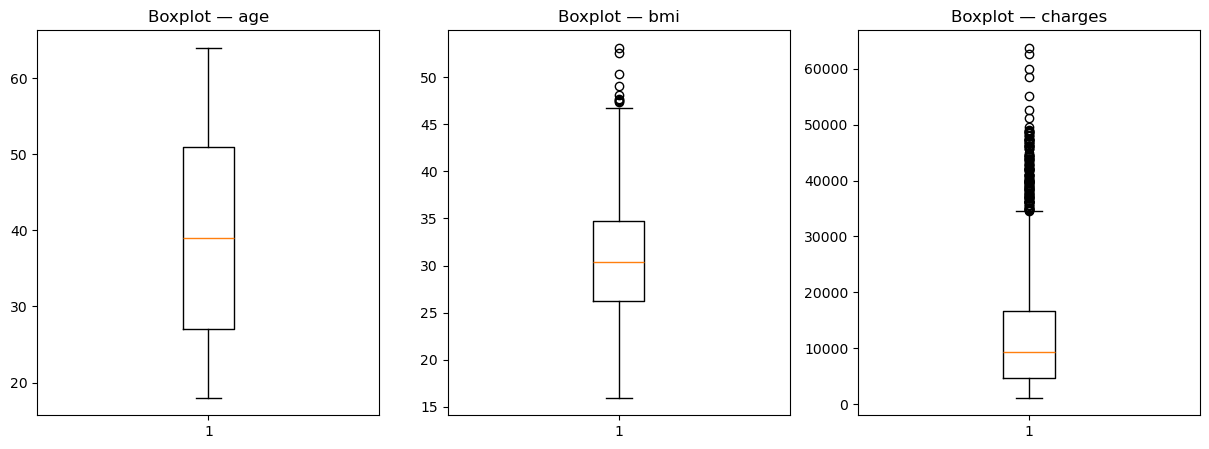

In [ ]:
# numerical columns:
# plot to visually detect outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['age', 'bmi', 'charges']):
    ax.boxplot(df[col])
    ax.set_title(f'Boxplot — {col}')

plt.show()

In [ ]:
# quanitfy outliers using IQR method
for col in ['age', 'bmi', 'charges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (below {lower:.1f} or above {upper:.1f})")

# outliers detected in bmi and charges

age: 0 outliers (below -9.0 or above 87.0)
bmi: 9 outliers (below 13.7 or above 47.3)
charges: 139 outliers (below -13120.7 or above 34524.8)


In [ ]:
# investigate bmi outliers' validity
print(f"Max BMI: {df['bmi'].max()}")
print(f"Min BMI: {df['bmi'].min()}")

# both min and max values are valid, so outliers will be kept for analysis

Max BMI: 53.13
Min BMI: 15.96


In [ ]:
# investigate charges outliers' validity
print(f"Max charges: {df['charges'].max()}")
print(f"Min charges: {df['charges'].min()}")

# both min and max values are valid, so outliers will be kept for analysis

Max charges: 63770.42801
Min charges: 1121.8739


## 🧹 Data Cleaning Summary

| Check | Finding | Action Taken |
|---|---|---|
| Missing values | 0 across all columns | None required |
| Duplicate rows | 1 duplicate row found | Removed row |
| Categorical validity | All values match expected categories | None required |
| Numeric ranges | BMI and Charges contain outliers (9 & 139) | Extra investigation |
| BMI outliers | All values are valid | Preserved outliers |
| Charges outliers | All values are valid | Preserved outliers |


### Outlier Decisions

**BMI**
- Max value is 53.13, min is 15.96
- No values below 10 or above 100 were found
- High BMI values (> 40) represent severe obesity (Class 3)
- Removing the clinically justified values would  weaken the BMI–charges relationship to be tested

**Charges**
- Max is 63770, min is 1,121 — no zero or negative values exist in the data
- Really high values represent real high-cost cases, not errors
- Removing them would bias the regression against the patients that drive costs

### Conclusion

Dataset is now clean and ready for analysis.
